In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.insert(0,"/Users/louaness/Documents/cohesin_residence_time/ipa/utils/")
import analysis_utils as utils

# Functions for plotting

In [3]:
def perform_analysis(pattern:list,nuclei_to_exclude:list) -> pd.DataFrame:
    """
    Perform iFRAP analysis
    :param pattern: list of strings with the pattern of the files to be analyzed
    :param nuclei_to_exclude: list of strings with the nuclei to be excluded from the analysis
    :return: DataFrame with iFRAP data + df average + df standard deviation (in time)
    """
    df = utils.concat_runs(pattern)

    utils.normalize_ifrap(df)
    df = df[~df.nucleus.isin(nuclei_to_exclude)]

    df_average = df.iloc[:, :-1].groupby('time').mean().reset_index()
    df_sd = df.iloc[:, :-1].groupby('time').std().reset_index()
    return df,df_average,df_sd

def plot_ifrap(df:pd.DataFrame,df_average:pd.DataFrame,df_sd:pd.DataFrame)->plt.Figure:
    """
    Plot iFRAP data
    :param df: DataFrame with iFRAP data
    :param df_average: DataFrame with time-average iFRAP data
    :param df_sd: DataFrame with time-standard-deviation iFRAP data
    :return: Figure with iFRAP data
    """
    a = plt.figure()
    sns.scatterplot(data=df,x='time',y='iFRAP',hue='nucleus',markers='.',linewidth=0,palette='tab20',s=8,alpha=1,legend=True)
    plt.plot(df_average.time.unique(),df_average.iFRAP,label='mean',c='black',linewidth=2, linestyle='--')
    plt.fill_between(df_average.time.unique(),df_average.iFRAP-df_sd.iFRAP,df_average.iFRAP+df_sd.iFRAP,alpha=0.5,label='std',color='grey')
    plt.xlim(4,250)
    plt.ylim(0.1,1.1)
    plt.legend(loc='upper right',bbox_to_anchor=(1.2,1.1))
    plt.xlabel('Time(frames)')
    return a 


# Import the data for NIPBL -dtag

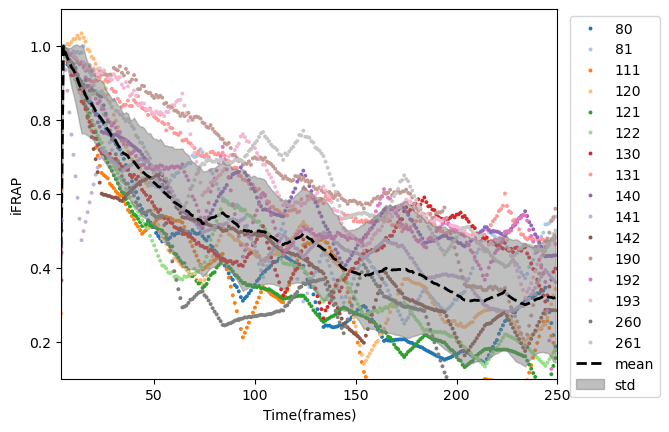

In [5]:
df_nipbl,df_nipbl_average,df_nipbl_sd = perform_analysis(['NIPBL', 'nodtag'],[123,143,2,0,191,132,1,110,82,290,291,292,293,294,295])
a = plot_ifrap(df_nipbl,df_nipbl_average,df_nipbl_sd)
plt.legend(loc='upper right',bbox_to_anchor=(1.22,1.0))
plt.show()

# NIPBL +dtag 

Error, the file 20240220_FRAP_NIPBL_FKBP_6h_dtag_LP_30_1 could not be opened, might not contain data or is not analized yet.
Error, the file 20240207_FRAP_NIPBL_FKBP_6hdtag_LP_30_s1_illustration could not be opened, might not contain data or is not analized yet.


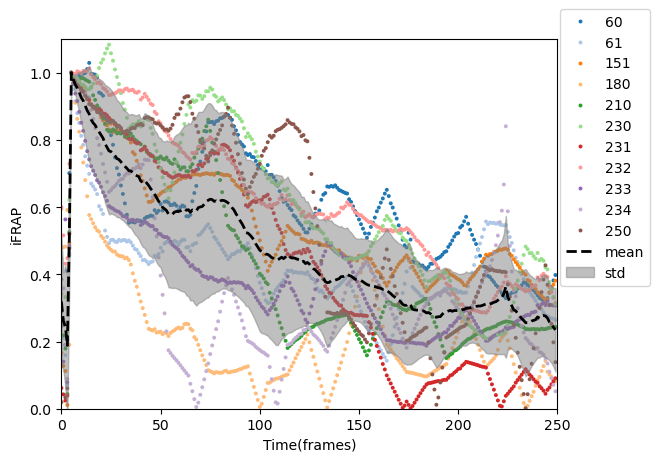

In [7]:
df_nipbl_dtag,df_nipbl_dtag_average,df_nipbl_dtag_sd = perform_analysis(['NIPBL_FKBP', '6hdtag','6h_dtag'],[235,211,212,150])
_ = plot_ifrap(df_nipbl_dtag,df_nipbl_dtag_average,df_nipbl_dtag_sd)

plt.xlim(0,250)
plt.ylim(0.,1.1)
plt.show()

# WAPL -aux

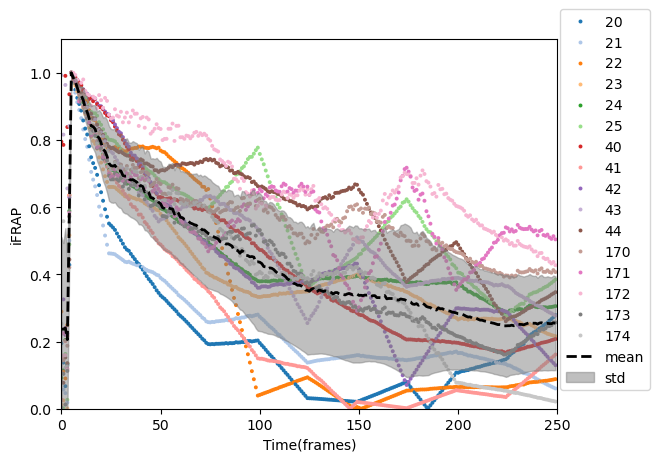

In [8]:
df_wapl,df_wapl_average,df_wapl_sd = perform_analysis(['WAPL', 'noaux'],[175,45])
_ = plot_ifrap(df_wapl,df_wapl_average,df_wapl_sd)
plt.xlim(0,250)
plt.ylim(0,1.1)
plt.show()

# WAPL +aux

Error, the file 20240205_FRAP_WAPL_AID_6h_aux_LP_30_s0 could not be opened, might not contain data or is not analized yet.


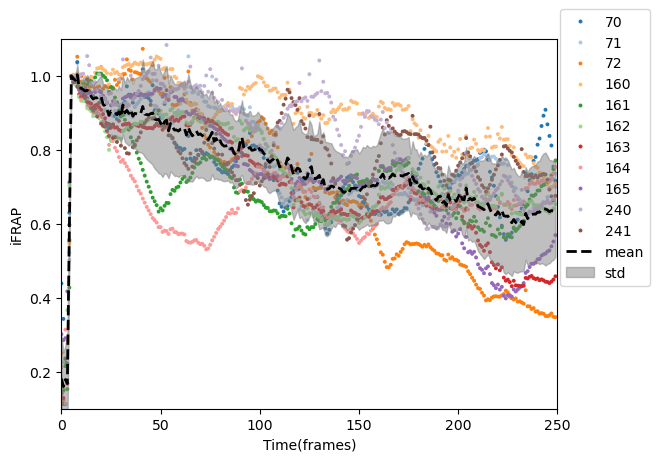

In [9]:
df_wapl_aux,df_wapl_aux_average,df_wapl_aux_sd = perform_analysis(['WAPL', '6h_aux','6haux'],[])
_ = plot_ifrap(df_wapl_aux,df_wapl_aux_average,df_wapl_aux_sd)
plt.xlim(0,250)

plt.show()


# WT 

(0.0, 1.1)

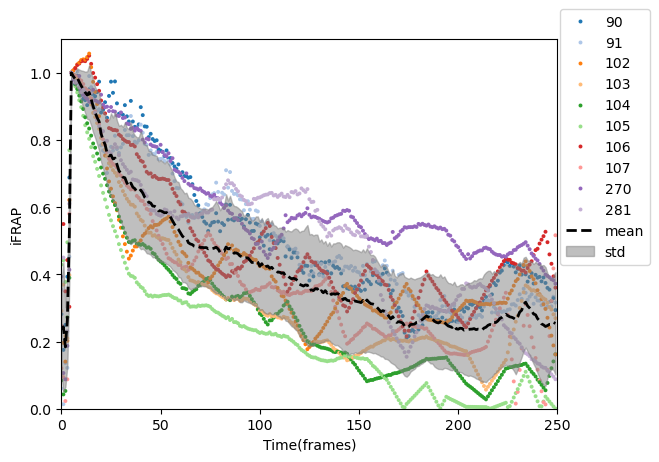

In [10]:
df_wt,df_wt_average,df_wt_sd = perform_analysis(['WT', 'RAD21'],[100,101,280])
_ = plot_ifrap(df_wt,df_wt_average,df_wt_sd)

plt.xlim(0,250)
plt.ylim(0,1.1)

# Fitting

In [11]:
# compute offset
offset = []
for df in [df_nipbl,df_nipbl_dtag,df_wapl,df_wapl_aux,df_wt]:
    offset.append(utils.compute_offset(df))

offset = np.mean(offset)

In [12]:
(popt_wt,pcov_wt,sd_wt), (popt_wapl,pcov_wapl,sd_wapl), (popt_nipbl,pcov_nipbl,sd_nipbl), (popt_nipbl_dtag,pcov_nipbl_dtag,sd_nipbl_dtag),(popt_wapl_aux,pcov_wapl_aux,sd_wapl_aux) = [utils.fit_df(df,offset) for df in [df_wt_average,df_wapl_average,df_nipbl_average,df_nipbl_dtag_average,df_wapl_aux_average]] 

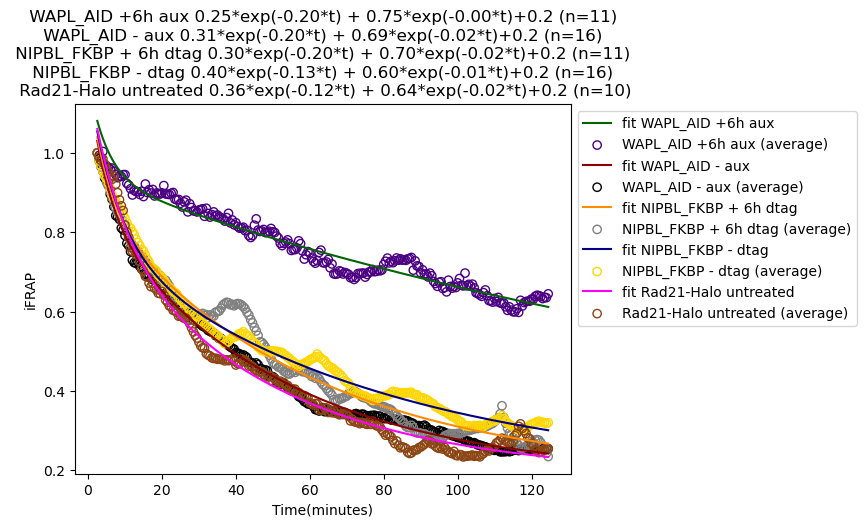

In [14]:
num_nuclei_condition1 = len(df_wapl_aux.nucleus.unique())
num_nuclei_condition2 = len(df_wapl.nucleus.unique())
num_nuclei_condition3 = len(df_nipbl_dtag.nucleus.unique())
num_nuclei_condition4 = len(df_nipbl.nucleus.unique())
num_nuclei_condition5 = len(df_wt.nucleus.unique())

x_wapl = df_wapl_average.time.unique()[5:]
x_wapl = x_wapl*0.5
x_wapl_aux = df_wapl_aux_average.time.unique()[5:]
x_wapl_aux = x_wapl_aux*0.5
x_nipbl = df_nipbl_average.time.unique()[5:]
x_nipbl = x_nipbl*0.5
x_nipbl_dtag = df_nipbl_dtag_average.time.unique()[5:]
x_nipbl_dtag = x_nipbl_dtag*0.5
x_wt = df_wt_average.time.unique()[5:]
x_wt = x_wt*0.5

y_wapl = df_wapl_average.iFRAP[5:]
y_wapl_aux = df_wapl_aux_average.iFRAP[5:]
y_nipbl = df_nipbl_average.iFRAP[5:]
y_nipbl_dtag = df_nipbl_dtag_average.iFRAP[5:]
y_wt = df_wt_average.iFRAP[5:]

plt.plot(x_wapl_aux,utils.double_exp(x_wapl_aux,*popt_wapl_aux,offset),label='fit WAPL_AID +6h aux',c='darkgreen')
plt.scatter(x_wapl_aux,y_wapl_aux,label='WAPL_AID +6h aux (average)',edgecolor='indigo',linewidth=1,facecolor='none')

plt.plot(x_wapl,utils.double_exp(x_wapl,*popt_wapl,offset),label='fit WAPL_AID - aux',c='darkred')
plt.scatter(x_wapl,y_wapl,label='WAPL_AID - aux (average)',edgecolor='black',linewidth=1,facecolor='none')

plt.plot(x_nipbl_dtag,utils.double_exp(x_nipbl_dtag,*popt_nipbl_dtag,offset),label='fit NIPBL_FKBP + 6h dtag',c='darkorange')
plt.scatter(x_nipbl_dtag,y_nipbl_dtag,label='NIPBL_FKBP + 6h dtag (average)',edgecolor='grey',linewidth=1,facecolor='none')

plt.plot(x_nipbl,utils.double_exp(x_nipbl,*popt_nipbl,offset),label='fit NIPBL_FKBP - dtag',c='navy')
plt.scatter(x_nipbl,y_nipbl,label='NIPBL_FKBP - dtag (average)',edgecolor='gold',linewidth=1,facecolor='none')

plt.plot(x_wt,utils.double_exp(x_wt,*popt_wt,offset),label='fit Rad21-Halo untreated',c='magenta')
plt.scatter(x_wt,y_wt,label='Rad21-Halo untreated (average)',edgecolor='saddlebrown',linewidth=1,facecolor='none')


plt.title(f' WAPL_AID +6h aux {popt_wapl_aux[0]:.2f}*exp(-{popt_wapl_aux[1]:.2f}*t) + {1-popt_wapl_aux[0]:.2f}*exp(-{popt_wapl_aux[2]:.2f}*t)+{0.2} (n={num_nuclei_condition1}) \n WAPL_AID - aux {popt_wapl[0]:.2f}*exp(-{popt_wapl[1]:.2f}*t) + {1-popt_wapl[0]:.2f}*exp(-{popt_wapl[2]:.2f}*t)+{0.2} (n={num_nuclei_condition2}) \n NIPBL_FKBP + 6h dtag {popt_nipbl_dtag[0]:.2f}*exp(-{popt_nipbl_dtag[1]:.2f}*t) + {1-popt_nipbl_dtag[0]:.2f}*exp(-{popt_nipbl_dtag[2]:.2f}*t)+{0.2} (n={num_nuclei_condition3}) \n NIPBL_FKBP - dtag {popt_nipbl[0]:.2f}*exp(-{popt_nipbl[1]:.2f}*t) + {1-popt_nipbl[0]:.2f}*exp(-{popt_nipbl[2]:.2f}*t)+{0.2} (n={num_nuclei_condition4}) \n Rad21-Halo untreated {popt_wt[0]:.2f}*exp(-{popt_wt[1]:.2f}*t) + {1-popt_wt[0]:.2f}*exp(-{popt_wt[2]:.2f}*t)+{0.2} (n={num_nuclei_condition5})')
plt.ylabel('iFRAP')
plt.xlabel('Time(minutes)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
# plt.savefig('../plots/iFRAP_curves.pdf',dpi=600,bbox_inches='tight')
plt.show()

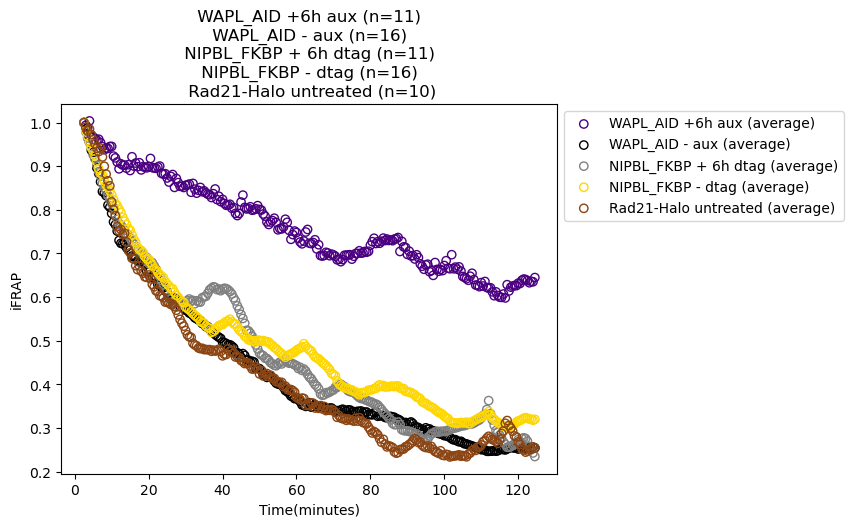

In [16]:
num_nuclei_condition1 = len(df_wapl_aux.nucleus.unique())
num_nuclei_condition2 = len(df_wapl.nucleus.unique())
num_nuclei_condition3 = len(df_nipbl_dtag.nucleus.unique())
num_nuclei_condition4 = len(df_nipbl.nucleus.unique())
num_nuclei_condition5 = len(df_wt.nucleus.unique())

x_wapl = df_wapl_average.time.unique()[5:]
x_wapl = x_wapl*0.5
x_wapl_aux = df_wapl_aux_average.time.unique()[5:]
x_wapl_aux = x_wapl_aux*0.5
x_nipbl = df_nipbl_average.time.unique()[5:]
x_nipbl = x_nipbl*0.5
x_nipbl_dtag = df_nipbl_dtag_average.time.unique()[5:]
x_nipbl_dtag = x_nipbl_dtag*0.5
x_wt = df_wt_average.time.unique()[5:]
x_wt = x_wt*0.5

y_wapl = df_wapl_average.iFRAP[5:]
y_wapl_aux = df_wapl_aux_average.iFRAP[5:]
y_nipbl = df_nipbl_average.iFRAP[5:]
y_nipbl_dtag = df_nipbl_dtag_average.iFRAP[5:]
y_wt = df_wt_average.iFRAP[5:]

# plt.plot(x_wapl_aux,utils.double_exp(x_wapl_aux,*popt_wapl_aux,offset),label='fit WAPL_AID +6h aux',c='darkgreen')
plt.scatter(x_wapl_aux,y_wapl_aux,label='WAPL_AID +6h aux (average)',edgecolor='indigo',linewidth=1,facecolor='none')

# plt.plot(x_wapl,utils.double_exp(x_wapl,*popt_wapl,offset),label='fit WAPL_AID - aux',c='darkred')
plt.scatter(x_wapl,y_wapl,label='WAPL_AID - aux (average)',edgecolor='black',linewidth=1,facecolor='none')

# plt.plot(x_nipbl_dtag,utils.double_exp(x_nipbl_dtag,*popt_nipbl_dtag,offset),label='fit NIPBL_FKBP + 6h dtag',c='darkorange')
plt.scatter(x_nipbl_dtag,y_nipbl_dtag,label='NIPBL_FKBP + 6h dtag (average)',edgecolor='grey',linewidth=1,facecolor='none')

# plt.plot(x_nipbl,utils.double_exp(x_nipbl,*popt_nipbl,offset),label='fit NIPBL_FKBP - dtag',c='navy')
plt.scatter(x_nipbl,y_nipbl,label='NIPBL_FKBP - dtag (average)',edgecolor='gold',linewidth=1,facecolor='none')

# plt.plot(x_wt,utils.double_exp(x_wt,*popt_wt,offset),label='fit Rad21-Halo untreated',c='magenta')
plt.scatter(x_wt,y_wt,label='Rad21-Halo untreated (average)',edgecolor='saddlebrown',linewidth=1,facecolor='none')


plt.title(f' WAPL_AID +6h aux (n={num_nuclei_condition1}) \n WAPL_AID - aux (n={num_nuclei_condition2}) \n NIPBL_FKBP + 6h dtag (n={num_nuclei_condition3}) \n NIPBL_FKBP - dtag (n={num_nuclei_condition4}) \n Rad21-Halo untreated (n={num_nuclei_condition5})')
plt.ylabel('iFRAP')
plt.xlabel('Time(minutes)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
# plt.savefig('../plots/iFRAP_curves.pdf',dpi=600,bbox_inches='tight')
plt.show()

## Fitting per condition

### NIPBL $\pm$ dtag

In [84]:
num_nuclei_condition5 = len(df_wt.nucleus.unique())
x_wt = df_wt_average.time.unique()[5:]
x_wt = 0.5*x_wt

y_wt = df_wt_average.iFRAP[5:]

In [67]:
from scipy.optimize import curve_fit
from functools import partial

In [82]:
num_nuclei_condition3 = len(df_nipbl_dtag.nucleus.unique())
num_nuclei_condition4 = len(df_nipbl.nucleus.unique())

x_nipbl = df_nipbl_average.time.unique()[5:]
x_nipbl = x_nipbl*0.5 # convert to minute (0.5s-1 frame rate)
x_nipbl_dtag = df_nipbl_dtag_average.time.unique()[5:]
x_nipbl_dtag = x_nipbl_dtag*0.5 # convert to minute (0.5s-1 frame rate)

y_nipbl = df_nipbl_average.iFRAP[5:]
y_nipbl_dtag = df_nipbl_dtag_average.iFRAP[5:]

partial_double_exp = partial(utils.double_exp,offset=offset)

popt_nipbl,_ = curve_fit(partial_double_exp, x_nipbl, y_nipbl,p0=[0.5,0.075,0.01],bounds=([0,0.05,0.001],[1,0.2,0.021]))

partial_double_expk2 = partial(utils.double_exp,k2=popt_nipbl[2],offset=offset)
popt_nipbl_dtag,_ = curve_fit(partial_double_expk2, x_nipbl_dtag, y_nipbl_dtag,p0=[0.5,0.075],bounds=([0,0.05],[1,0.2]))

popt_wt,_ = curve_fit(partial_double_exp, x_wt, y_wt,p0=[0.5,0.075,0.01],bounds=([0,0.05,0.001],[1,0.2,0.021]))

print(popt_nipbl)
print(popt_nipbl_dtag)
print(popt_wt)


[0.39917073 0.13286491 0.01333289]
[0.43437202 0.11416841]
[0.35753755 0.12073909 0.021     ]


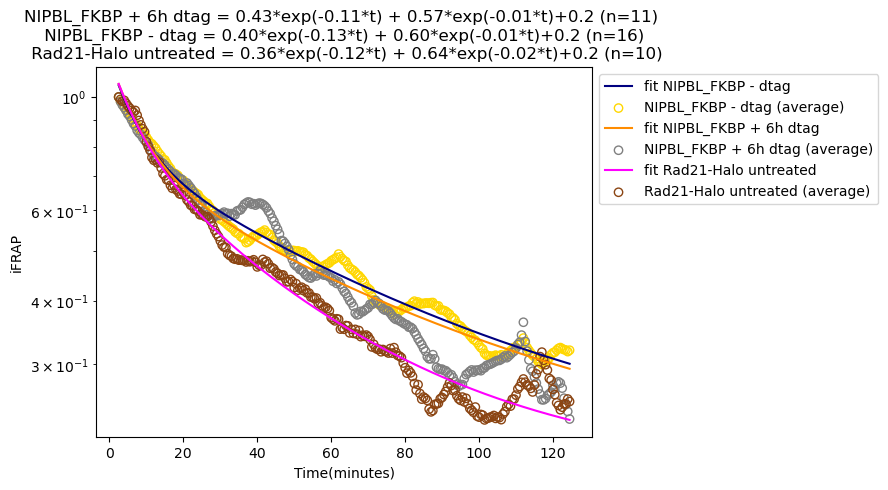

In [85]:
sns.lineplot(x=x_nipbl,y=utils.double_exp(x_nipbl,*popt_nipbl,offset),label='fit NIPBL_FKBP - dtag',c='navy')
plt.scatter(x_nipbl,y_nipbl,label='NIPBL_FKBP - dtag (average)',edgecolor='gold',linewidth=1,facecolor='none')

sns.lineplot(x=x_nipbl_dtag,y=utils.double_exp(x_nipbl_dtag,popt_nipbl_dtag[0],popt_nipbl_dtag[1],popt_nipbl[2],offset),label='fit NIPBL_FKBP + 6h dtag',c='darkorange')
plt.scatter(x_nipbl_dtag,y_nipbl_dtag,label='NIPBL_FKBP + 6h dtag (average)',edgecolor='grey',linewidth=1,facecolor='none')

sns.lineplot(x=x_wt,y=utils.double_exp(x_wt,*popt_wt,offset),label='fit Rad21-Halo untreated',c='magenta')
plt.scatter(x_wt,y_wt,label='Rad21-Halo untreated (average)',edgecolor='saddlebrown',linewidth=1,facecolor='none')

plt.yscale('log')

plt.title(f'NIPBL_FKBP + 6h dtag = {popt_nipbl_dtag[0]:.2f}*exp(-{popt_nipbl_dtag[1]:.2f}*t) + {1-popt_nipbl_dtag[0]:.2f}*exp(-{popt_nipbl[2]:.2f}*t)+{0.2} (n={num_nuclei_condition3}) \n NIPBL_FKBP - dtag = {popt_nipbl[0]:.2f}*exp(-{popt_nipbl[1]:.2f}*t) + {1-popt_nipbl[0]:.2f}*exp(-{popt_nipbl[2]:.2f}*t)+{0.2} (n={num_nuclei_condition4}) \n Rad21-Halo untreated = {popt_wt[0]:.2f}*exp(-{popt_wt[1]:.2f}*t) + {1-popt_wt[0]:.2f}*exp(-{popt_wt[2]:.2f}*t)+{0.2} (n={num_nuclei_condition5})')
plt.ylabel('iFRAP')
plt.xlabel('Time(minutes)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.show()

### WAPL $\pm$ AUX

In [70]:
num_nuclei_condition1 = len(df_wapl_aux.nucleus.unique())
num_nuclei_condition2 = len(df_wapl.nucleus.unique())

x_wapl = df_wapl_average.time.unique()[5:]
x_wapl = x_wapl*0.5
x_wapl_aux = df_wapl_aux_average.time.unique()[5:]
x_wapl_aux = x_wapl_aux*0.5

y_wapl = df_wapl_average.iFRAP[5:]
y_wapl_aux = df_wapl_aux_average.iFRAP[5:]

partial_double_exp = partial(utils.double_exp,offset=offset)

popt_wapl,_ = curve_fit(partial_double_exp, x_wapl, y_wapl,p0=[0.5,0.075,0.01],bounds=([0,0.05,0.001],[1,0.2,0.021]))

partial_double_expk1 = partial(utils.double_exp,k2=popt_wapl[1],offset=offset)

popt_wapl_aux,_ = curve_fit(partial_double_expk1, x_wapl_aux, y_wapl_aux,p0=[0.5,0.01],bounds=([0,0.001],[1,0.021]))

print(popt_wapl)
print(popt_nipbl_dtag)


[0.31038569 0.2        0.0202388 ]
[0.43437202 0.11416841]


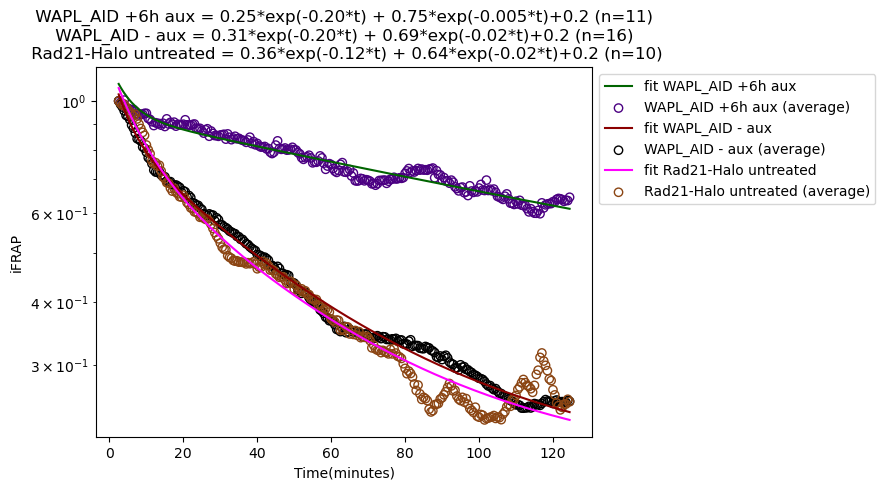

In [86]:
plt.plot(x_wapl_aux,utils.double_exp(x_wapl_aux,popt_wapl_aux[0],popt_wapl_aux[1],popt_wapl[1],offset),label='fit WAPL_AID +6h aux',c='darkgreen')
plt.scatter(x_wapl_aux,y_wapl_aux,label='WAPL_AID +6h aux (average)',edgecolor='indigo',linewidth=1,facecolor='none')

plt.plot(x_wapl,utils.double_exp(x_wapl,*popt_wapl,offset),label='fit WAPL_AID - aux',c='darkred')
plt.scatter(x_wapl,y_wapl,label='WAPL_AID - aux (average)',edgecolor='black',linewidth=1,facecolor='none')

sns.lineplot(x=x_wt,y=utils.double_exp(x_wt,*popt_wt,offset),label='fit Rad21-Halo untreated',c='magenta')
plt.scatter(x_wt,y_wt,label='Rad21-Halo untreated (average)',edgecolor='saddlebrown',linewidth=1,facecolor='none')


plt.title(f' WAPL_AID +6h aux = {1-popt_wapl_aux[0]:.2f}*exp(-{popt_wapl[1]:.2f}*t) + {popt_wapl_aux[0]:.2f}*exp(-{popt_wapl_aux[1]:.3f}*t)+{0.2} (n={num_nuclei_condition1}) \n WAPL_AID - aux = {popt_wapl[0]:.2f}*exp(-{popt_wapl[1]:.2f}*t) + {1-popt_wapl[0]:.2f}*exp(-{popt_wapl[2]:.2f}*t)+{0.2} (n={num_nuclei_condition2}) \n Rad21-Halo untreated = {popt_wt[0]:.2f}*exp(-{popt_wt[1]:.2f}*t) + {1-popt_wt[0]:.2f}*exp(-{popt_wt[2]:.2f}*t)+{0.2} (n={num_nuclei_condition5})')

plt.yscale('log')
plt.ylabel('iFRAP')
plt.xlabel('Time(minutes)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.show()